In [5]:
£
# -*- coding: utf-8 -*-
monTexte = "Heureusement que les variables existent"
print(monTexte)
print(monTexte)
input("Tapez ENTREE")



Python 3.13.0 (v3.13.0:60403a5409f, Oct  7 2024, 00:37:40) [Clang 15.0.0 (clang-1500.3.9.4)] on darwin
Type "help", "copyright", "credits" or "license" for more information.
=
>>> >
KeyboardInterrupt
=
>>> 
>=
>>> Heureusement que les variables existent
Heureusement que les variables existent


KeyboardInterrupt: Interrupted by user

In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
monTexte = "Heureusement que la boucle FOR existe"
for compteur in range(5) :
    print(monTexte)

In [6]:
monTexte = "Heureusement que la boucle FOR existe"

for compteur in range(5):
    print(monTexte)

Heureusement que la boucle FOR existe
Heureusement que la boucle FOR existe
Heureusement que la boucle FOR existe
Heureusement que la boucle FOR existe
Heureusement que la boucle FOR existe


In [7]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
monTexte = "Heureusement que la boucle FOR existe"
for compteur in range(5) :
    print(compteur)
    print(monTexte)
input("Tapez sur ENTREE")

0
Heureusement que la boucle FOR existe
1
Heureusement que la boucle FOR existe
2
Heureusement que la boucle FOR existe
3
Heureusement que la boucle FOR existe
4
Heureusement que la boucle FOR existe


''

In [9]:
monTexte = "Un peu de patience !"
for compteur in range(500) :
    print(compteur, "   ", monTexte)
input("Tapez sur ENTREE")

0     Un peu de patience !
1     Un peu de patience !
2     Un peu de patience !
3     Un peu de patience !
4     Un peu de patience !
5     Un peu de patience !
6     Un peu de patience !
7     Un peu de patience !
8     Un peu de patience !
9     Un peu de patience !
10     Un peu de patience !
11     Un peu de patience !
12     Un peu de patience !
13     Un peu de patience !
14     Un peu de patience !
15     Un peu de patience !
16     Un peu de patience !
17     Un peu de patience !
18     Un peu de patience !
19     Un peu de patience !
20     Un peu de patience !
21     Un peu de patience !
22     Un peu de patience !
23     Un peu de patience !
24     Un peu de patience !
25     Un peu de patience !
26     Un peu de patience !
27     Un peu de patience !
28     Un peu de patience !
29     Un peu de patience !
30     Un peu de patience !
31     Un peu de patience !
32     Un peu de patience !
33     Un peu de patience !
34     Un peu de patience !
35     Un peu de patience !
36

''

In [13]:
# -*- coding: utf-8 -*-

R = int(input("Valeur de R en Ohm ? "))
print("U(V)\tI(A)")

for I in range(11):   # von 0 bis 10 inklusive
    U = R * I
    print(U, "\t", I)

input("Tapez sur ENTREE")

U(V)	I(A)
0 	 0
2 	 1
4 	 2
6 	 3
8 	 4
10 	 5
12 	 6
14 	 7
16 	 8
18 	 9
20 	 10


''

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ======================================
# Excel-Datei laden
# ======================================
df = pd.read_excel("Reines Wasser.xlsx", engine="openpyxl",
                   usecols="A,B", skiprows=3, nrows=589)
df.columns = ["Zeit", "Temperatur"]

# ======================================
# Lineare Regression im Bereich 520–590 s
# ======================================
fit_mask = (df["Zeit"] >= 520) & (df["Zeit"] <= 590)
x_tan = df.loc[fit_mask, "Zeit"].values
y_tan = df.loc[fit_mask, "Temperatur"].values

def lin(x, m, b):
    return m * x + b

# Curve Fit mit Kovarianzmatrix
popt, pcov = curve_fit(lin, x_tan, y_tan)
m, b = popt
σ_m, σ_b = np.sqrt(np.diag(pcov))
cov_mb = pcov[0, 1]

# ======================================
# Bestimmtheitsmaß R²
# ======================================
y_pred = lin(x_tan, *popt)
ss_res = np.sum((y_tan - y_pred) ** 2)
ss_tot = np.sum((y_tan - np.mean(y_tan)) ** 2)
r2 = 1 - ss_res / ss_tot

# ======================================
# Schnittpunkt mit Abkühlkurve finden
# ======================================
df["Tangente"] = lin(df["Zeit"], *popt)
df["Delta"] = df["Temperatur"] - df["Tangente"]
wechsel_idx = np.where(np.diff(np.sign(df["Delta"])))[0][0]
x_schnitt = df["Zeit"].iloc[wechsel_idx]
y_schnitt = df["Tangente"].iloc[wechsel_idx]

# ======================================
# Standardfehler des Gefrierpunkts
# ======================================
σ_T = np.sqrt(x_schnitt**2 * σ_m**2 + σ_b**2 + 2 * x_schnitt * cov_mb)

# ======================================
# Plot
# ======================================
plt.figure(figsize=(8, 6))

# Messwerte (blau)
plt.plot(df["Zeit"], df["Temperatur"], color="blue", lw=2, label="Messwerte")

# Tangente (rot, gestrichelt)
plt.plot(df["Zeit"], df["Tangente"], color="red", linestyle="--", lw=2,
         label=f"Tangente: y = {m:.3f}x + {b:.2f}")

# Horizontale Linie am Schnittpunkt (grün, gepunktet)
plt.hlines(y_schnitt, 0, x_schnitt, color="green", linestyle=":", lw=2,
           label=fr"$T_{{\mathrm{{Gefrierpunkt}}}} = {y_schnitt:.2f} \pm {σ_T:.2f}\,^{{\circ}}\mathrm{{C}}$")

# Gefrierpunkt markieren
plt.plot(x_schnitt, y_schnitt, "ko", label="Gefrierpunkt")

# Achsenbeschriftung, Titel, Legende
plt.xlabel("Zeit / s")
plt.ylabel("Temperatur / °C")
plt.title("Graph 1: Abkühlkurve mit Gefrierpunkt")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

# ======================================
# Ausgaben
# ======================================
print(f"R² der Tangente           : {r2:.4f}")
print(f"Gefrierpunkt              : {y_schnitt:.2f} °C")
print(f"Standardfehler (1 σ)      : ±{σ_T:.2f} °C")
print(f"Fit-Parameter m, b        : {m:.5f} ± {σ_m:.5f},  {b:.2f} ± {σ_b:.2f}")

FileNotFoundError: [Errno 2] No such file or directory: 'Reines Wasser.xlsx'

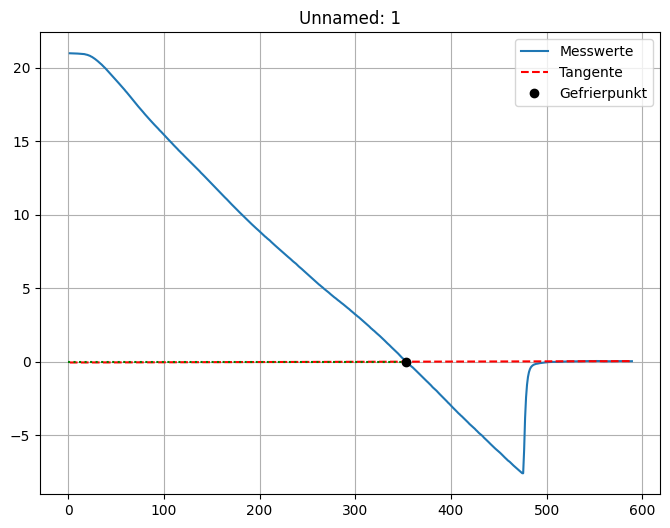

Unnamed: 1: Gefrierpunkt 0.02 °C, R²=0.1449


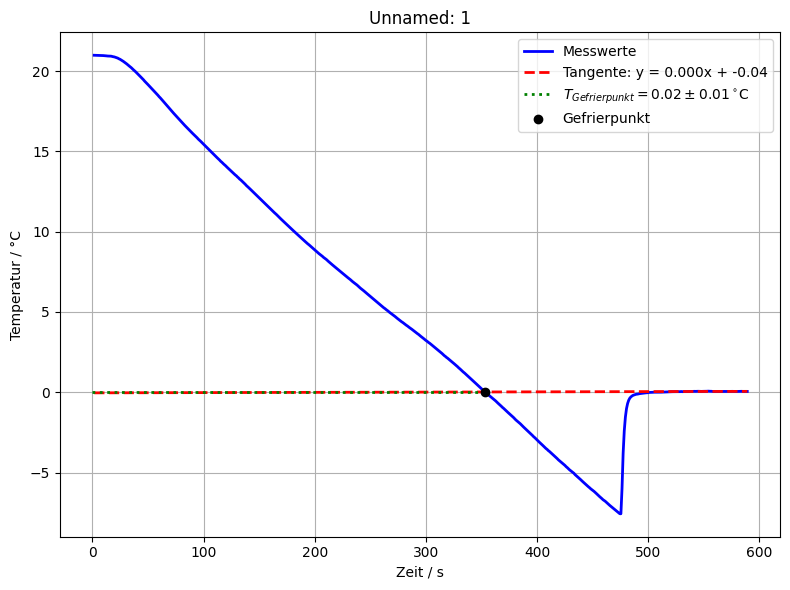

Messreihe                : Unnamed: 1
R² der Tangente          : 0.1449
Gefrierpunkt             : 0.02 °C
Standardfehler (1 σ)     : ±0.01 °C
Fit-Parameter m, b       : 0.00016 ± 0.00005,  -0.04 ± 0.03



In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ======================================
# Hilfsfunktion: lineare Funktion
# ======================================
def lin(x, m, b):
    return m * x + b


# ======================================
# Excel einlesen
# ======================================
df = pd.read_excel("Exp 4 KryoskopieTest.xlsx", sheet_name="Tabelle1", engine="openpyxl")

# Die erste Spalte ist die Zeit (wenn das bei dir so ist!)
zeit = df.iloc[:, 0].values

# Alle anderen Spalten enthalten Temperaturen verschiedener Messungen
spalten = df.columns[1:]  # alle außer der Zeitspalte

# ======================================
# Loop über alle Messreihen
# ======================================
for name in spalten:
    # Spalte in Zahlen umwandeln (Text → NaN)
    temperatur = pd.to_numeric(df[name], errors='coerce').values

    # Nur Zeilen mit gültigen Werten
    mask = ~np.isnan(temperatur)
    x = zeit[mask]
    y = temperatur[mask]

    # Überspringen, wenn Spalte komplett leer oder unbrauchbar ist
    if len(y) < 10:
        continue

    # Fit-Bereich
    fit_mask = (x >= 520) & (x <= 590)
    if not np.any(fit_mask):
        continue

    x_tan = x[fit_mask]
    y_tan = y[fit_mask]

    popt, pcov = curve_fit(lin, x_tan, y_tan)
    m, b = popt
    σ_m, σ_b = np.sqrt(np.diag(pcov))
    cov_mb = pcov[0, 1]

    y_pred = lin(x_tan, *popt)
    ss_res = np.sum((y_tan - y_pred) ** 2)
    ss_tot = np.sum((y_tan - np.mean(y_tan)) ** 2)
    r2 = 1 - ss_res / ss_tot

    # Schnittpunkt
    y_tangente = lin(x, *popt)
    delta = y - y_tangente
    wechsel = np.where(np.diff(np.sign(delta)))[0]
    if len(wechsel) == 0:
        continue
    idx = wechsel[0]
    x_schnitt = x[idx]
    y_schnitt = y_tangente[idx]
    σ_T = np.sqrt(x_schnitt**2 * σ_m**2 + σ_b**2 + 2 * x_schnitt * cov_mb)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(x, y, label="Messwerte")
    plt.plot(x, y_tangente, "r--", label="Tangente")
    plt.hlines(y_schnitt, 0, x_schnitt, "g", linestyle=":")
    plt.plot(x_schnitt, y_schnitt, "ko", label="Gefrierpunkt")
    plt.title(name)
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"{name}: Gefrierpunkt {y_schnitt:.2f} °C, R²={r2:.4f}")

    # ======================================
    # Plot für diese Messung
    # ======================================
    plt.figure(figsize=(8, 6))
    plt.plot(x, y, color="blue", lw=2, label="Messwerte")
    plt.plot(x, y_tangente, "r--", lw=2, label=f"Tangente: y = {m:.3f}x + {b:.2f}")
    plt.hlines(y_schnitt, 0, x_schnitt, color="green", linestyle=":", lw=2,
               label=fr"$T_{{Gefrierpunkt}} = {y_schnitt:.2f} \pm {σ_T:.2f}\,^{{\circ}}\mathrm{{C}}$")
    plt.plot(x_schnitt, y_schnitt, "ko", label="Gefrierpunkt")

    plt.xlabel("Zeit / s")
    plt.ylabel("Temperatur / °C")
    plt.title(f"{name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ======================================
    # Ausgabe in Konsole
    # ======================================
    print("=====================================")
    print(f"Messreihe                : {name}")
    print(f"R² der Tangente          : {r2:.4f}")
    print(f"Gefrierpunkt             : {y_schnitt:.2f} °C")
    print(f"Standardfehler (1 σ)     : ±{σ_T:.2f} °C")
    print(f"Fit-Parameter m, b       : {m:.5f} ± {σ_m:.5f},  {b:.2f} ± {σ_b:.2f}")
    print("=====================================\n")

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ---------- Hilfsfunktion ----------
def lin(x, m, b):
    return m * x + b

# ---------- 1. Daten laden ----------
df = pd.read_excel(
    "Exp 4 KryoskopieTest.xlsx",   # <-- hier dein Dateiname
    sheet_name="Tabelle1",         # <-- hier dein Tabellenblatt-Name
    engine="openpyxl",
    header=3
)

# Wir nehmen an: erste Spalte = Zeit
zeit = pd.to_numeric(df.iloc[:, 0], errors='coerce').values

# Alle restlichen Spalten = Temperaturkurven
spalten = df.columns[1:]  # überspringt Zeitspalte


# ---------- 2. Fit-Bereiche für jede Messung definieren ----------
# Schlüssel = Spaltenname in Excel
# Wert = (t_min, t_max) Bereich, der linear (~Tangente vorm Schnitt) ist
bereiche = {
    ("Reines Wasser 1",   "Zeit",    "Temp",    520, 590),
    ("Reines Wasser 2",   "Zeit.1",  "Temp.1",  520, 590),
    ("Reines Wasser 3",   "Zeit.2",  "Temp.2",  520, 590),

    ("2.5 wt% 1",         "Zeit.3",  "Temp.3",  250, 300),
    ("2.5 wt% 2",         "Zeit.4",  "Temp.4",  250, 300),
    ("2.5 wt% 3",         "Zeit.5",  "Temp.5",  250, 300),

    ("5 wt% 1",           "Zeit.6",  "Temp.6",  220, 280),
    ("5 wt% 2",           "Zeit.7",  "Temp.7",  220, 280),
    ("5 wt% 3",           "Zeit.8",  "Temp.8",  220, 280),

    ("7.5 wt% 1",         "Zeit.9",   "Temp.9",   200, 260),
    ("7.5 wt% 2",         "Zeit.10",  "Temp.10",  200, 260),
    ("7.5 wt% 3",         "Zeit.11",  "Temp.11",  200, 260),

    ("10 wt% 1",          "Zeit.12", "Temp.12",  180, 240),
    ("10 wt% 2",          "Zeit.13", "Temp.13",  180, 240),
    ("10 wt% 3",          "Zeit.14", "Temp.14",  180, 240)}

# ---------- 3. Schleife über jede Messreihe ----------
results = []  # sammeln für späteren Export, falls du willst

for name in spalten:
    print(f"\n=== Bearbeite: {name} ===")

    # Prüfen, ob wir wissen, welchen Fitbereich wir für diese Messreihe nehmen sollen
    if name not in bereiche:
        print(f"   -> Kein Fit-Bereich für '{name}' definiert. Überspringe.")
        continue

    t_min, t_max = bereiche[name]

    # Temperaturspalte in Zahlen wandeln (Text -> NaN)
    temperatur = pd.to_numeric(df[name], errors='coerce').values

    # Nur gültige Werte (keine NaNs)
    valid_mask = ~np.isnan(temperatur)
    x = zeit[valid_mask]
    y = temperatur[valid_mask]

    # Prüfen: Haben wir überhaupt Daten?
    if len(y) < 10:
        print("   -> Zu wenige Datenpunkte, überspringe.")
        continue

    # Fit-Bereich anwenden (z. B. 520-590 s oder 200-260 s, je nach Messung)
    fit_mask = (x >= t_min) & (x <= t_max)

    if not np.any(fit_mask):
        print(f"   -> In '{name}' gibt es keine Daten zwischen {t_min}s und {t_max}s. Überspringe.")
        continue

    x_tan = x[fit_mask]
    y_tan = y[fit_mask]

    # Lineare Regression in dem definierten Bereich
    popt, pcov = curve_fit(lin, x_tan, y_tan)
    m, b = popt
    σ_m, σ_b = np.sqrt(np.diag(pcov))
    cov_mb = pcov[0, 1]

    # Bestimmtheitsmaß R²
    y_pred = lin(x_tan, *popt)
    ss_res = np.sum((y_tan - y_pred) ** 2)
    ss_tot = np.sum((y_tan - np.mean(y_tan)) ** 2)
    r2 = 1 - ss_res / ss_tot

    # Tangente über gesamten Zeitbereich
    y_tangente = lin(x, *popt)

    # Schnittpunkt: Stelle, wo Messkurve und Tangente sich schneiden
    delta = y - y_tangente
    wechsel = np.where(np.diff(np.sign(delta)))[0]
    if len(wechsel) == 0:
        print("   -> Kein Schnittpunkt gefunden, überspringe.")
        continue

    idx = wechsel[0]
    x_schnitt = x[idx]
    y_schnitt = y_tangente[idx]

    # Fehlerfortpflanzung für T_Gefrierpunkt
    σ_T = np.sqrt(
        x_schnitt**2 * σ_m**2 +
        σ_b**2 +
        2 * x_schnitt * cov_mb
    )

    # ---------- Plot ----------
    plt.figure(figsize=(8, 6))
    plt.plot(x, y, lw=2, label="Messwerte")
    plt.plot(x, y_tangente, "r--", lw=2,
             label=f"Tangente: y = {m:.3f}x + {b:.2f}")
    plt.hlines(y_schnitt, x.min(), x_schnitt, "g", linestyle=":",
               lw=2,
               label=fr"$T_{{Gefrierpunkt}} = {y_schnitt:.2f} \pm {σ_T:.2f}$ °C")
    plt.plot(x_schnitt, y_schnitt, "ko", label="Gefrierpunkt")

    plt.xlabel("Zeit / s")
    plt.ylabel("Temperatur / °C")
    plt.title(f"{name}  (Fit: {t_min}–{t_max} s)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------- Konsole-Output ----------
    print(f"   Gefrierpunkt           : {y_schnitt:.2f} °C")
    print(f"   Unsicherheit (1σ)      : ±{σ_T:.2f} °C")
    print(f"   R² des Fits            : {r2:.4f}")
    print(f"   m, b                   : {m:.5f} ± {σ_m:.5f},  {b:.2f} ± {σ_b:.2f}")
    print(f"   verwendeter Fit-Bereich: {t_min}s – {t_max}s")

    # ---------- Ergebnis merken ----------
    results.append({
        "Messreihe": name,
        "Fit von [s]": t_min,
        "Fit bis [s]": t_max,
        "Gefrierpunkt [°C]": y_schnitt,
        "Fehler [°C]": σ_T,
        "R²": r2,
        "m": m,
        "σ_m": σ_m,
        "b": b,
        "σ_b": σ_b
    })

# Optional: Am Ende eine Tabelle aller Ergebnisse anzeigen
if results:
    summary_df = pd.DataFrame(results)
    print("\n===== Zusammenfassung aller Messreihen =====")
    print(summary_df)



=== Bearbeite: Zeit ===
   -> Kein Fit-Bereich für 'Zeit' definiert. Überspringe.

=== Bearbeite: Temp ===
   -> Kein Fit-Bereich für 'Temp' definiert. Überspringe.

=== Bearbeite: Reines Wasser.1 ===
   -> Kein Fit-Bereich für 'Reines Wasser.1' definiert. Überspringe.

=== Bearbeite: Zeit.1 ===
   -> Kein Fit-Bereich für 'Zeit.1' definiert. Überspringe.

=== Bearbeite: Temp.1 ===
   -> Kein Fit-Bereich für 'Temp.1' definiert. Überspringe.

=== Bearbeite: Reines Wasser.2 ===
   -> Kein Fit-Bereich für 'Reines Wasser.2' definiert. Überspringe.

=== Bearbeite: Zeit.2 ===
   -> Kein Fit-Bereich für 'Zeit.2' definiert. Überspringe.

=== Bearbeite: Temp.2 ===
   -> Kein Fit-Bereich für 'Temp.2' definiert. Überspringe.

=== Bearbeite: 2.5 wt% ===
   -> Kein Fit-Bereich für '2.5 wt%' definiert. Überspringe.

=== Bearbeite: Zeit.3 ===
   -> Kein Fit-Bereich für 'Zeit.3' definiert. Überspringe.

=== Bearbeite: Temp.3 ===
   -> Kein Fit-Bereich für 'Temp.3' definiert. Überspringe.

=== Bearbeit

In [36]:
print(df.columns)

Index(['Reines Wasser', 'Zeit', 'Temp', 'Reines Wasser.1', 'Zeit.1', 'Temp.1',
       'Reines Wasser.2', 'Zeit.2', 'Temp.2', '2.5 wt%', 'Zeit.3', 'Temp.3',
       '2.5 wt%.1', 'Zeit.4', 'Temp.4', '2.5 wt%.2', 'Zeit.5', 'Temp.5',
       '5wt%', 'Zeit.6', 'Temp.6', '5wt%.1', 'Zeit.7', 'Temp.7', '5wt%.2',
       'Zeit.8', 'Temp.8', '7.5wt%', 'Zeit.9', 'Temp.9', '7.5wt%.1', 'Zeit.10',
       'Temp.10', '7.5wt%.2', 'Zeit.11', 'Temp.11', 'Unnamed: 36', '10wt%',
       'Zeit.12', 'Temp.12', '10wt%.1', 'Zeit.13', 'Temp.13', '10wt%.2',
       'Zeit.14', 'Temp.14'],
      dtype='object')


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ---------- Hilfsfunktion ----------
def lin(x, m, b):
    return m * x + b

# ---------- 1. Daten laden ----------
df = pd.read_excel(
    "Exp 4 KryoskopieTest.xlsx",   # Dateiname ggf. anpassen
    sheet_name="Tabelle1",         # Blattname ggf. anpassen
    engine="openpyxl",
    header=3                       # hast du ja schon so gewählt
)

# ---------- 2. Beschreibung aller Messreihen ----------
# Key = wie die Messreihe heißen soll (für Plot/Tabelle)
# Value = (Zeitspalte, Temperaturspalte, t_min, t_max)
bereiche = {
    "Reines Wasser 1": ("Zeit",   "Temp",    520, 590),
    "Reines Wasser 2": ("Zeit.1", "Temp.1",  400, 450),
    "Reines Wasser 3": ("Zeit.2", "Temp.2",  520, 590),

    "2.5 wt% 1":       ("Zeit.3", "Temp.3",  250, 300),
    "2.5 wt% 2":       ("Zeit.4", "Temp.4",  250, 300),
    "2.5 wt% 3":       ("Zeit.5", "Temp.5",  250, 300),

    "5 wt% 1":         ("Zeit.6", "Temp.6",  220, 280),
    "5 wt% 2":         ("Zeit.7", "Temp.7",  220, 280),
    "5 wt% 3":         ("Zeit.8", "Temp.8",  220, 280),

    "7.5 wt% 1":       ("Zeit.9",  "Temp.9",  200, 260),
    "7.5 wt% 2":       ("Zeit.10", "Temp.10", 200, 260),
    "7.5 wt% 3":       ("Zeit.11", "Temp.11", 150, 190),

    "10 wt% 1":        ("Zeit.12", "Temp.12", 300, 360),
    "10 wt% 2":        ("Zeit.13", "Temp.13", 180, 240),
    "10 wt% 3":        ("Zeit.14", "Temp.14", 180, 240),
}

results = []

# ---------- 3. Schleife über jede definierte Messreihe ----------
for mess_name, (zeit_col, temp_col, t_min, t_max) in bereiche.items():
    print(f"\n=== Bearbeite: {mess_name} ===")

    # Prüfen ob Spalten überhaupt existieren (z. B. falls leere Messung)
    if zeit_col not in df.columns or temp_col not in df.columns:
        print(f"   -> Spalten {zeit_col}/{temp_col} nicht gefunden. Überspringe.")
        continue

    # Rohdaten aus dieser Messung holen und in Zahlen umwandeln
    x_raw = pd.to_numeric(df[zeit_col], errors="coerce").values
    y_raw = pd.to_numeric(df[temp_col], errors="coerce").values

    # NaN rauswerfen
    valid_mask = ~np.isnan(x_raw) & ~np.isnan(y_raw)
    x = x_raw[valid_mask]
    y = y_raw[valid_mask]

    if len(x) < 10:
        print("   -> Zu wenige Datenpunkte. Überspringe.")
        continue

    # Fit-Bereich anwenden
    fit_mask = (x >= t_min) & (x <= t_max)
    x_tan = x[fit_mask]
    y_tan = y[fit_mask]

# Fit-Bereich anwenden (z. B. 520–590 s)
fit_mask = (x >= t_min) & (x <= t_max)

# Prüfen, ob überhaupt Punkte im Bereich liegen
if not np.any(fit_mask):
    print(f"   -> Kein Fitbereich {t_min}-{t_max}s in den Daten. Überspringe.")
    continue

# Fit-Daten extrahieren
x_tan = x[fit_mask]
y_tan = y[fit_mask]

# Falls zu wenige Punkte im Fitbereich, überspringen
if len(x_tan) < 3:
    print(f"   -> Zu wenige Punkte ({len(x_tan)}) im Fit-Bereich {t_min}-{t_max}s. Überspringe.")
    continue

    # Lineare Regression (Tangente)
    popt, pcov = curve_fit(lin, x_tan, y_tan)
    m, b = popt
    σ_m, σ_b = np.sqrt(np.diag(pcov))
    cov_mb = pcov[0, 1]

    # R²
    y_pred = lin(x_tan, *popt)
    ss_res = np.sum((y_tan - y_pred) ** 2)
    ss_tot = np.sum((y_tan - np.mean(y_tan)) ** 2)
    r2 = 1 - ss_res / ss_tot

    # Tangente über alle Zeiten
    y_tangente = lin(x, *popt)

    # Schnittpunkt Messkurve vs. Tangente
    delta = y - y_tangente
    wechsel = np.where(np.diff(np.sign(delta)))[0]
    if len(wechsel) == 0:
        print("   -> Kein Schnittpunkt gefunden. Überspringe.")
        continue

    idx = wechsel[0]
    x_schnitt = x[idx]
    y_schnitt = y_tangente[idx]

    # Fehlerfortpflanzung für T_Gefrierpunkt
    σ_T = np.sqrt(
        x_schnitt**2 * σ_m**2 +
        σ_b**2 +
        2 * x_schnitt * cov_mb
    )

    # Plot für diese Messreihe
    plt.figure(figsize=(8, 6))
    plt.plot(x, y, lw=2, label="Messwerte")
    # Tangente nur bis kurz nach dem Schnittpunkt zeichnen
    x_tan_plot = x[(x >= x_schnitt - 40) & (x <= x.max())]   # +10 Sekunden nach dem Schnittpunkt (optional)
    y_tan_plot = lin(x_tan_plot, m, b)
    plt.plot(x_tan_plot, y_tan_plot, "r--", lw=2,
         label=f"Tangente (Fit bis Schnittpunkt): y = {m:.3f}x + {b:.2f}")
    plt.hlines(y_schnitt, x.min(), x_schnitt,
               linestyle=":", lw=2, color="green",
               label=f"Tgef = {y_schnitt:.2f} ± {σ_T:.2f} °C")
    plt.plot(x_schnitt, y_schnitt, "ko", label="Gefrierpunkt")

    plt.xlabel("Zeit / s")
    plt.ylabel("Temperatur / °C")
    plt.title(f"{mess_name}  (Fit {t_min}–{t_max} s)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Ergebnisse merken
    results.append({
        "Messreihe": mess_name,
        "Fit_von_s": t_min,
        "Fit_bis_s": t_max,
        "Gefrierpunkt_C": y_schnitt,
        "Fehler_C_1sigma": σ_T,
        "R2": r2,
        "m": m,
        "σ_m": σ_m,
        "b": b,
        "σ_b": σ_b,
    })

# Zusammenfassung am Ende
if results:
    summary_df = pd.DataFrame(results)
    print("\n===== Zusammenfassung =====")
    print(summary_df)


=== Bearbeite: Reines Wasser 1 ===

=== Bearbeite: Reines Wasser 2 ===

=== Bearbeite: Reines Wasser 3 ===

=== Bearbeite: 2.5 wt% 1 ===

=== Bearbeite: 2.5 wt% 2 ===

=== Bearbeite: 2.5 wt% 3 ===

=== Bearbeite: 5 wt% 1 ===

=== Bearbeite: 5 wt% 2 ===

=== Bearbeite: 5 wt% 3 ===

=== Bearbeite: 7.5 wt% 1 ===

=== Bearbeite: 7.5 wt% 2 ===

=== Bearbeite: 7.5 wt% 3 ===

=== Bearbeite: 10 wt% 1 ===

=== Bearbeite: 10 wt% 2 ===

=== Bearbeite: 10 wt% 3 ===


SyntaxError: 'continue' not properly in loop (2163843648.py, line 78)


=== Bearbeite: Reines Wasser 1 ===


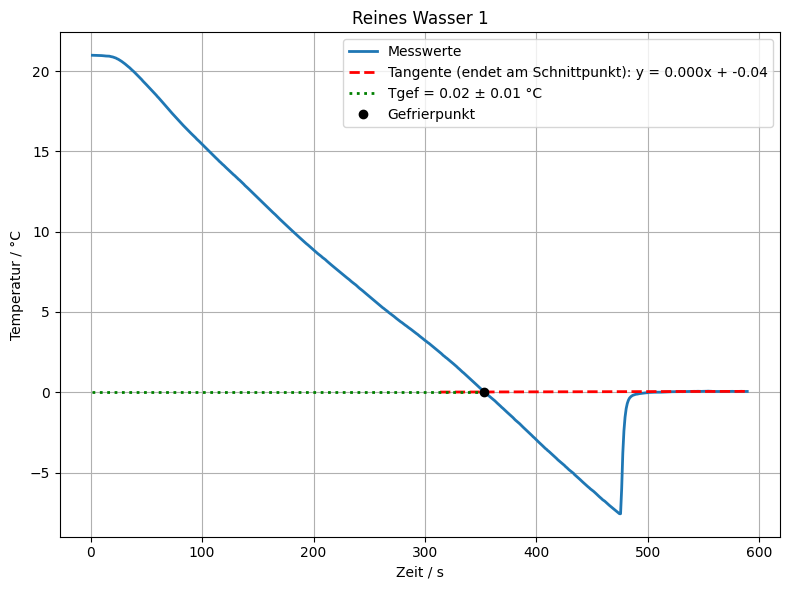


=== Bearbeite: Reines Wasser 2 ===


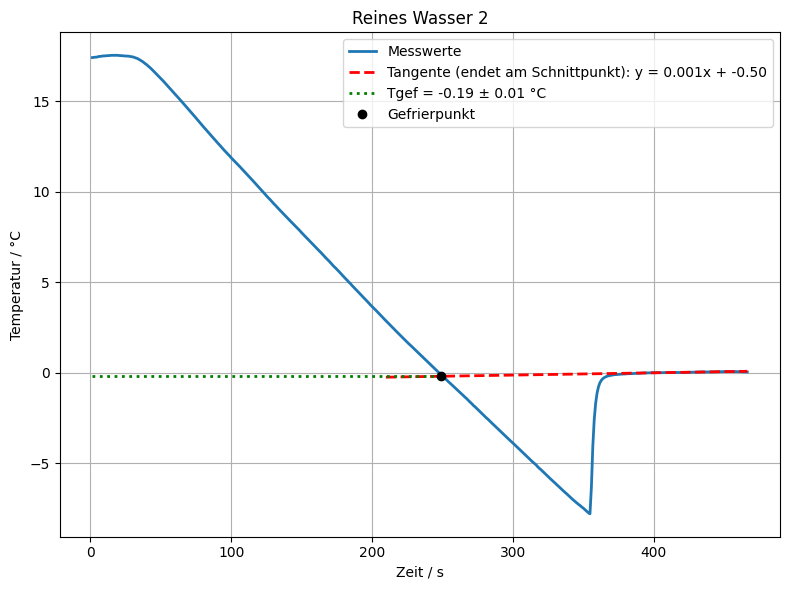


=== Bearbeite: Reines Wasser 3 ===


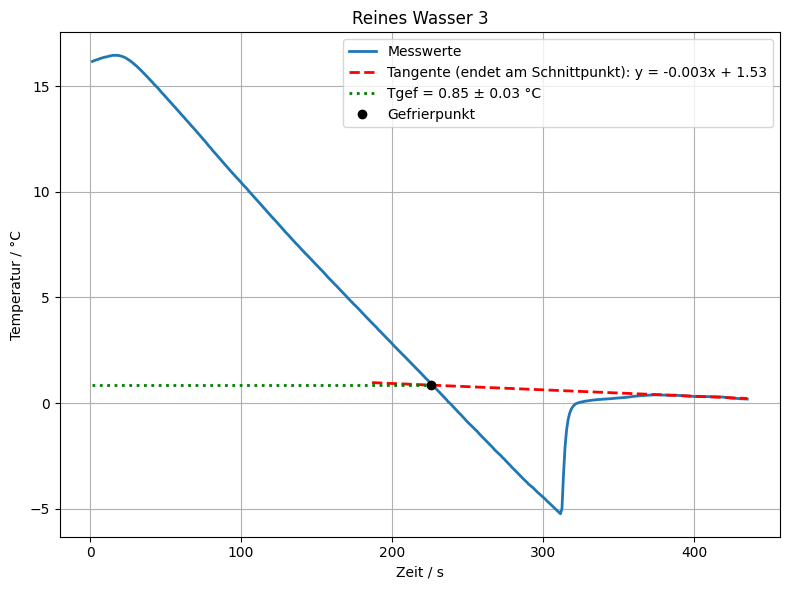


=== Bearbeite: 2.5 wt% 1 ===


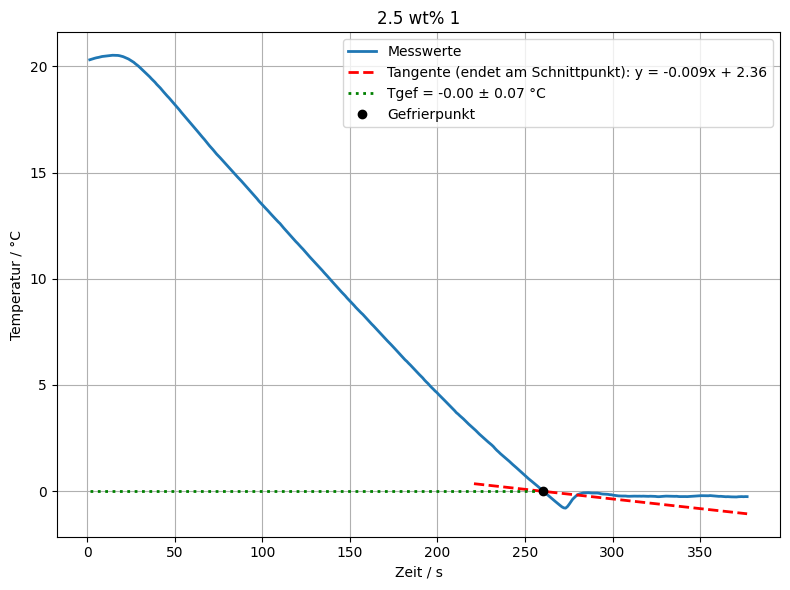


=== Bearbeite: 2.5 wt% 2 ===


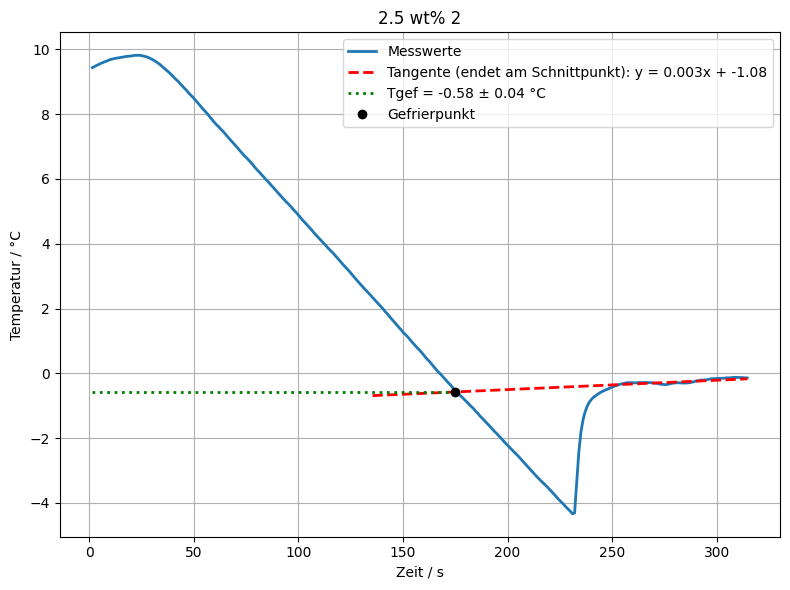


=== Bearbeite: 2.5 wt% 3 ===


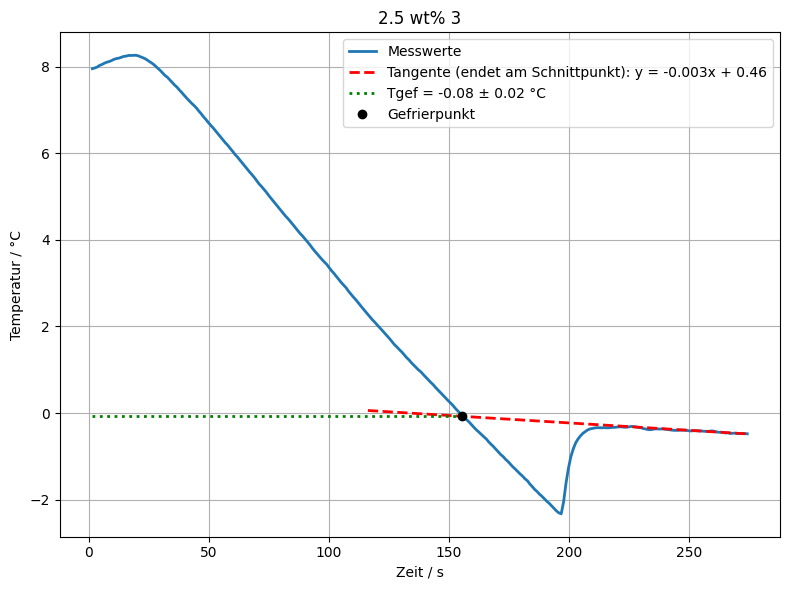


=== Bearbeite: 5 wt% 1 ===


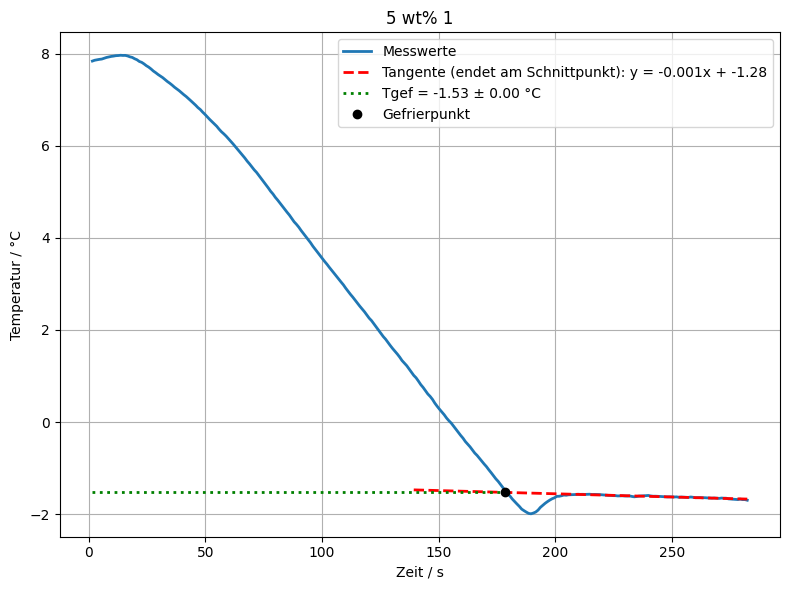


=== Bearbeite: 5 wt% 2 ===


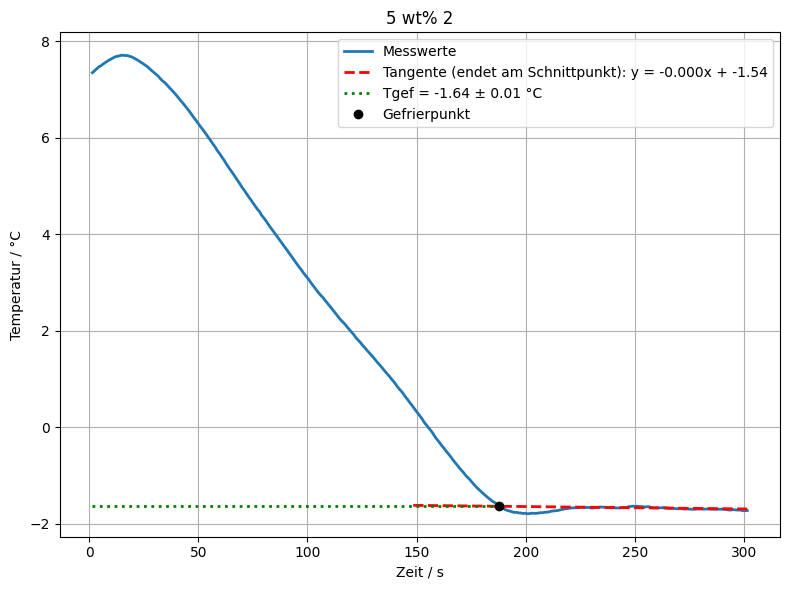


=== Bearbeite: 5 wt% 3 ===


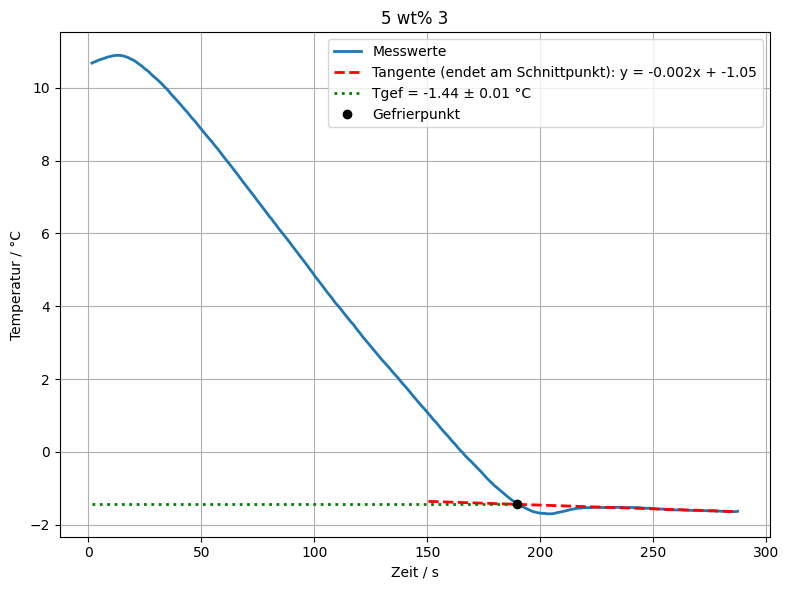


=== Bearbeite: 7.5 wt% 1 ===


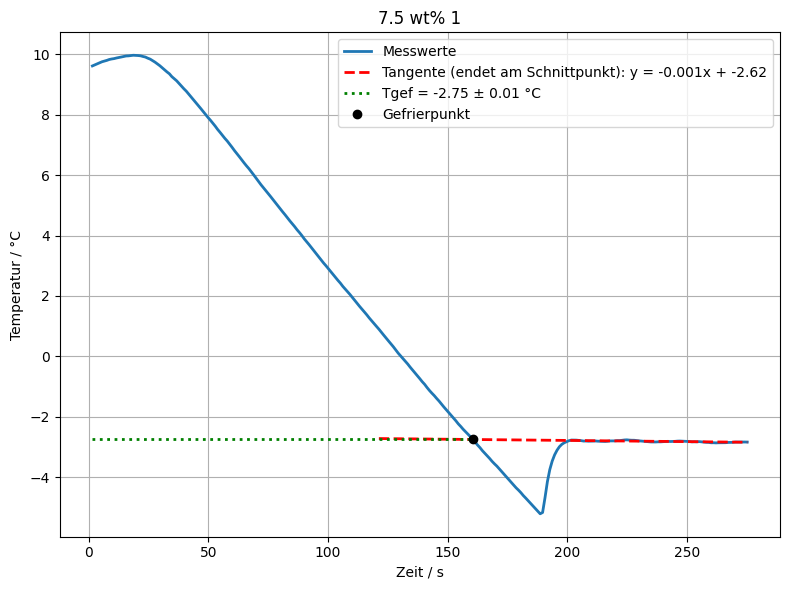


=== Bearbeite: 7.5 wt% 2 ===


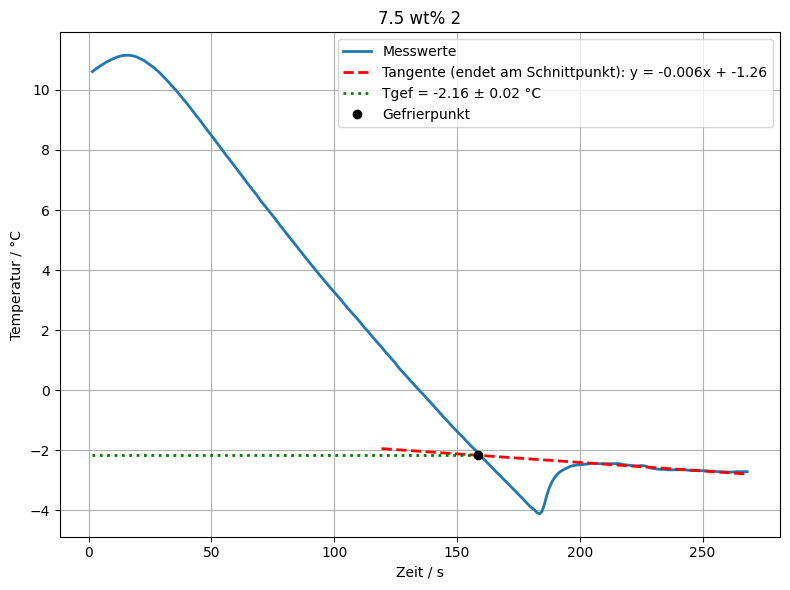


=== Bearbeite: 7.5 wt% 3 ===


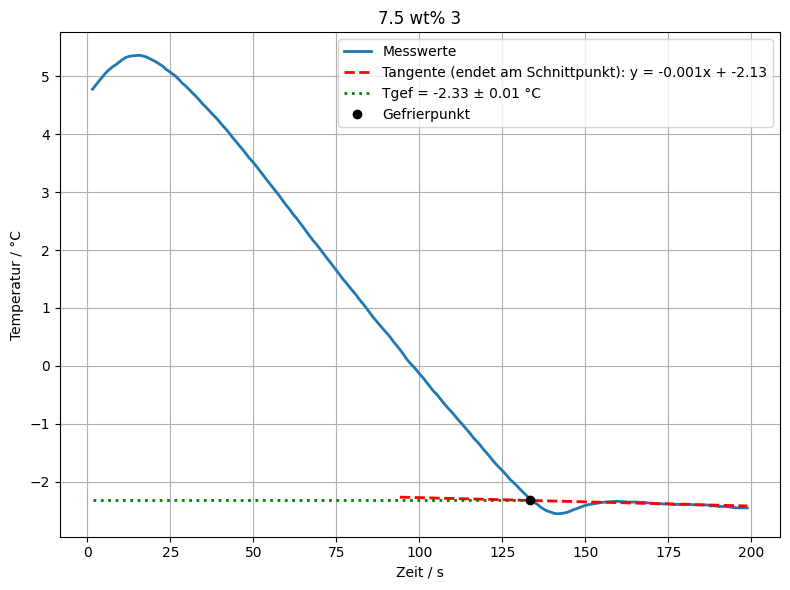


=== Bearbeite: 10 wt% 1 ===


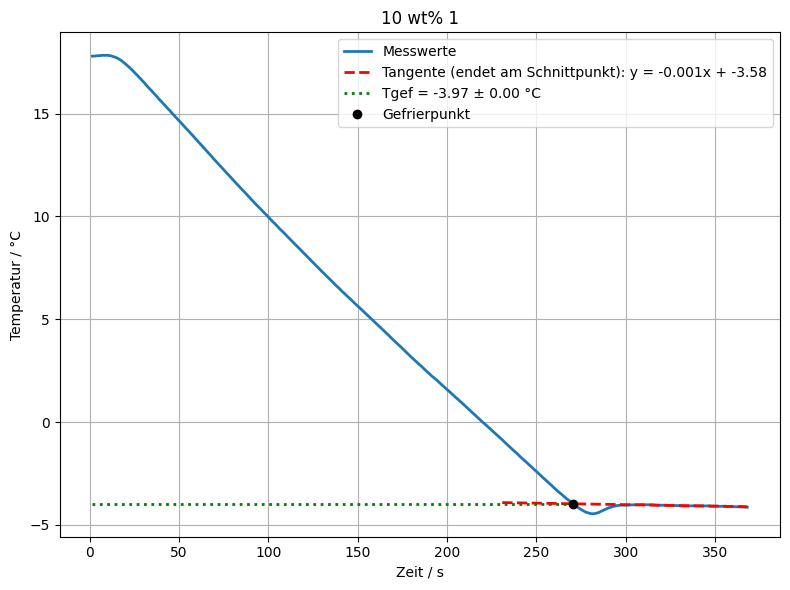


=== Bearbeite: 10 wt% 2 ===
   -> Zu wenige Punkte (1) im Fit-Bereich 180-240s. Überspringe.

=== Bearbeite: 10 wt% 3 ===


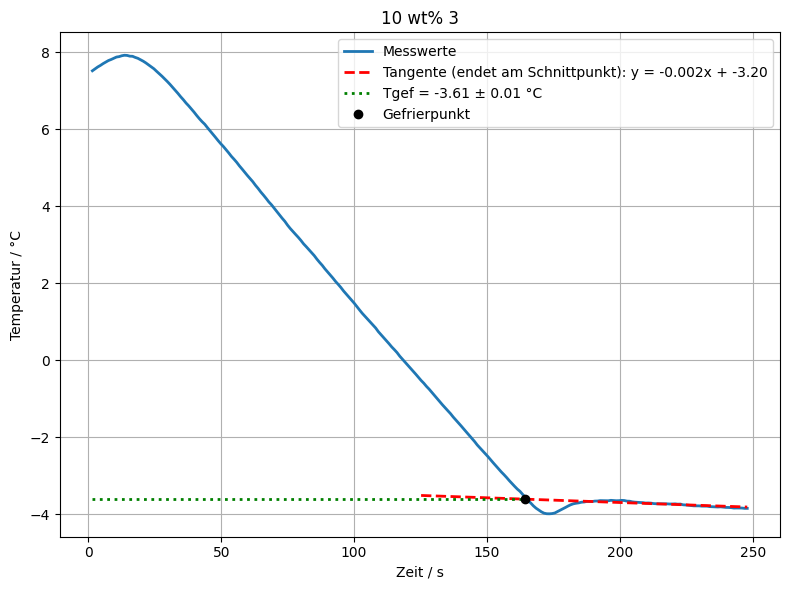


===== Zusammenfassung =====
          Messreihe  Fit_von_s  Fit_bis_s  Gefrierpunkt_C  Fehler_C_1sigma  \
0   Reines Wasser 1        520        590        0.016882         0.009485   
1   Reines Wasser 2        400        450       -0.188595         0.007749   
2   Reines Wasser 3        390        430        0.847693         0.033324   
3         2.5 wt% 1        250        300       -0.004619         0.068534   
4         2.5 wt% 2        250        300       -0.575508         0.036452   
5         2.5 wt% 3        250        300       -0.075211         0.022575   
6           5 wt% 1        220        280       -1.527209         0.003992   
7           5 wt% 2        220        280       -1.636090         0.006990   
8           5 wt% 3        220        280       -1.443492         0.005018   
9         7.5 wt% 1        200        260       -2.751512         0.008533   
10        7.5 wt% 2        200        260       -2.164526         0.015149   
11        7.5 wt% 3        150     

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ---------- Hilfsfunktion ----------
def lin(x, m, b):
    return m * x + b

# ---------- 1. Daten laden ----------
df = pd.read_excel(
    "Exp 4 KryoskopieTest.xlsx",   # Dateiname ggf. anpassen
    sheet_name="Tabelle1",         # Blattname ggf. anpassen
    engine="openpyxl",
    header=3                       # hast du ja schon so gewählt
)

# ---------- 2. Beschreibung aller Messreihen ----------
bereiche = {
    "Reines Wasser 1": ("Zeit",   "Temp",    520, 590),
    "Reines Wasser 2": ("Zeit.1", "Temp.1",  400, 450),
    "Reines Wasser 3": ("Zeit.2", "Temp.2",  390, 430),

    "2.5 wt% 1":       ("Zeit.3", "Temp.3",  250, 300),
    "2.5 wt% 2":       ("Zeit.4", "Temp.4",  250, 300),
    "2.5 wt% 3":       ("Zeit.5", "Temp.5",  250, 300),

    "5 wt% 1":         ("Zeit.6", "Temp.6",  220, 280),
    "5 wt% 2":         ("Zeit.7", "Temp.7",  220, 280),
    "5 wt% 3":         ("Zeit.8", "Temp.8",  220, 280),

    "7.5 wt% 1":       ("Zeit.9",  "Temp.9",  200, 260),
    "7.5 wt% 2":       ("Zeit.10", "Temp.10", 200, 260),
    "7.5 wt% 3":       ("Zeit.11", "Temp.11", 150, 190),

    "10 wt% 1":        ("Zeit.12", "Temp.12", 300, 360),
    "10 wt% 2":        ("Zeit.13", "Temp.13", 180, 240),
    "10 wt% 3":        ("Zeit.14", "Temp.14", 180, 240),
}

results = []

# ---------- 3. Schleife über jede definierte Messreihe ----------
for mess_name, (zeit_col, temp_col, t_min, t_max) in bereiche.items():
    print(f"\n=== Bearbeite: {mess_name} ===")

    # Prüfen, ob Spalten überhaupt existieren
    if zeit_col not in df.columns or temp_col not in df.columns:
        print(f"   -> Spalten {zeit_col}/{temp_col} nicht gefunden. Überspringe.")
        continue

    # Rohdaten holen
    x_raw = pd.to_numeric(df[zeit_col], errors="coerce").values
    y_raw = pd.to_numeric(df[temp_col], errors="coerce").values

    # NaN rauswerfen
    valid_mask = ~np.isnan(x_raw) & ~np.isnan(y_raw)
    x = x_raw[valid_mask]
    y = y_raw[valid_mask]

    if len(x) < 10:
        print("   -> Zu wenige Datenpunkte. Überspringe.")
        continue

    # ---------- Fit-Bereich anwenden ----------
    fit_mask = (x >= t_min) & (x <= t_max)

    # 1️⃣ Prüfen, ob überhaupt Punkte im Bereich liegen
    if not np.any(fit_mask):
        print(f"   -> Kein Fitbereich {t_min}-{t_max}s in den Daten. Überspringe.")
        continue

    # 2️⃣ Daten im Fitbereich holen
    x_tan = x[fit_mask]
    y_tan = y[fit_mask]

    # 3️⃣ Falls zu wenige Punkte im Fitbereich, überspringen
    if len(x_tan) < 3:
        print(f"   -> Zu wenige Punkte ({len(x_tan)}) im Fit-Bereich {t_min}-{t_max}s. Überspringe.")
        continue

    # ---------- Lineare Regression (Tangente) ----------
    popt, pcov = curve_fit(lin, x_tan, y_tan)
    m, b = popt
    σ_m, σ_b = np.sqrt(np.diag(pcov))
    cov_mb = pcov[0, 1]

    # Bestimmtheitsmaß R²
    y_pred = lin(x_tan, *popt)
    ss_res = np.sum((y_tan - y_pred) ** 2)
    ss_tot = np.sum((y_tan - np.mean(y_tan)) ** 2)
    r2 = 1 - ss_res / ss_tot

    # Tangente über alle Zeiten
    y_tangente = lin(x, *popt)

    # ---------- Schnittpunkt bestimmen ----------
    delta = y - y_tangente
    wechsel = np.where(np.diff(np.sign(delta)))[0]
    if len(wechsel) == 0:
        print("   -> Kein Schnittpunkt gefunden. Überspringe.")
        continue

    idx = wechsel[0]
    x_schnitt = x[idx]
    y_schnitt = y_tangente[idx]

    # ---------- Fehlerfortpflanzung ----------
    σ_T = np.sqrt(
        x_schnitt**2 * σ_m**2 +
        σ_b**2 +
        2 * x_schnitt * cov_mb
    )

    # ---------- Plot ----------
    plt.figure(figsize=(8, 6))
    plt.plot(x, y, lw=2, label="Messwerte")

    # Tangente nur bis kurz nach dem Schnittpunkt zeichnen
    x_tan_plot = x[(x >= x_schnitt - 40) & (x <= x.max())]
    y_tan_plot = lin(x_tan_plot, m, b)
    plt.plot(x_tan_plot, y_tan_plot, "r--", lw=2,
             label=f"Tangente (endet am Schnittpunkt): y = {m:.3f}x + {b:.2f}")

    # Horizontale Linie am Schnittpunkt
    plt.hlines(y_schnitt, x.min(), x_schnitt,
               linestyle=":", lw=2, color="green",
               label=f"Tgef = {y_schnitt:.2f} ± {σ_T:.2f} °C")

    plt.plot(x_schnitt, y_schnitt, "ko", label="Gefrierpunkt")

    plt.xlabel("Zeit / s")
    plt.ylabel("Temperatur / °C")
    plt.title(f"{mess_name}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------- Ergebnisse speichern ----------
    results.append({
        "Messreihe": mess_name,
        "Fit_von_s": t_min,
        "Fit_bis_s": t_max,
        "Gefrierpunkt_C": y_schnitt,
        "Fehler_C_1sigma": σ_T,
        "R2": r2,
        "m": m,
        "σ_m": σ_m,
        "b": b,
        "σ_b": σ_b,
    })

# ---------- Zusammenfassung ----------
if results:
    summary_df = pd.DataFrame(results)
    print("\n===== Zusammenfassung =====")
    print(summary_df)